# 04 Convolution, Filtering, and Matched Filters

## Purpose

This notebook turns Fourier intuition back into time-domain operations. The goal is to understand how linear time-invariant systems act on sampled signals, why convolution is the natural operation for filtering, how correlation differs from convolution, and why matched filters are so important in sonar and radar.

## Prerequisites

- Notebook 01: Signals, Systems, and Sampling
- Notebook 02: Sinusoids, Complex Exponentials, and Phase
- Notebook 03: Fourier Transform and Spectral Intuition
- Basic comfort with sampled sequences and spectra

## Learning Objectives

By the end of this notebook, you should be able to:

- explain what an impulse response means,
- interpret convolution as a sliding weighted sum,
- describe why low-pass filtering smooths fast variation,
- distinguish convolution from correlation,
- explain what a matched filter is doing geometrically,
- and connect matched-filter peaks to delay estimation and later pulse-compression ideas.


## New Terms In This Notebook

- **Linear time-invariant (LTI) system**: a system whose response scales linearly with the input and does not change when the input is shifted in time.
- **Impulse response**: the output of a system when the input is a unit impulse. For an LTI system, it fully characterizes the system.
- **Convolution**: the operation that combines an input sequence with an impulse response to produce the output of an LTI system.
- **Kernel**: the short weighting sequence used in convolution. In filtering problems, the kernel is the impulse response.
- **Low-pass filter**: a filter that preserves slower variation and attenuates faster variation.
- **Correlation**: a similarity measure between one sequence and a shifted reference sequence.
- **Matched filter**: a filter built from the time-reversed conjugate of a known reference waveform. It produces a strong output when the received data contains that waveform.
- **Complex conjugate**: for a complex number or sequence, conjugation flips the sign of the imaginary part. In real-valued examples, conjugation does nothing.
- **Delay estimate**: an estimate of when a reference waveform appears in the data, often taken from the peak of a correlation or matched-filter output.


## Big Picture

Notebook 03 asked which frequencies are present in the data. This notebook asks a different question: how does a system transform the data in time?

For linear time-invariant systems, convolution is the time-domain operation that describes that transformation. In this notebook, that idea becomes concrete through smoothing filters, correlation-based alignment, and matched filters for detection and delay estimation.

The big picture is that these are not separate tricks. They are closely related ways of combining a signal with a known response or reference waveform so that structure becomes easier to interpret, detect, or measure.

## Mathematical Definitions and Relevant Intuition

### Convolution For An LTI System

For a discrete-time linear time-invariant (LTI) system with input $x[n]$, impulse response $h[n]$, and output $y[n]$, the convolution sum is

$$
y[n] = (x * h)[n] = \sum_{m=-\infty}^{\infty} x[m] \, h[n-m].
$$

This equation says that the output at sample $n$ is built by collecting contributions from many input samples. The term $h[n-m]$ shifts a flipped copy of the impulse response across the input, and the sum adds all overlapping contributions.

### Why Convolution Has This Form

The intuition is that an LTI system responds to each input impulse in the same way, just shifted in time. A general input sequence can be viewed as a weighted sum of shifted impulses, so the total output is the sum of shifted and scaled copies of the impulse response. Convolution is the bookkeeping rule that performs that sum.

So convolution is not just an arbitrary formula. It is the mathematical statement of a simple idea: **each input sample launches a scaled copy of the impulse response, and the output is the sum of all those copies.**

### Correlation As A Similarity Test

For two discrete sequences $x[n]$ and $r[n]$, one common cross-correlation form is

$$
(x \star r)[n] = \sum_{m=-\infty}^{\infty} x[m] \, r^*[m-n].
$$

Correlation asks a different question from convolution. Instead of asking how a system transforms an input, it asks how similar one sequence is to a shifted copy of a reference sequence. Large correlation means the local shapes line up well at that shift.

### Matched Filter

For a known reference waveform $s[n]$, the matched-filter impulse response is

$$
h_{MF}[n] = s^*[-n],
$$

where the $^*$ symbol means complex conjugation. In the real-valued examples used here, conjugation does nothing, so this becomes simple time reversal.

If we insert that matched-filter impulse response into the convolution sum, we get

$$
y_{MF}[n] = \sum_{m=-\infty}^{\infty} x[m] \, h_{MF}[n-m]
= \sum_{m=-\infty}^{\infty} x[m] \, s^*[m-n].
$$

That final expression has the same structure as correlation. This is the key point:

- the **negative sign** inside $s^*[-n]$ creates the time reversal needed so convolution lines up a shifted copy of the reference with the data,
- the **conjugation** makes the operation work correctly for complex signals, preserving phase-sensitive alignment instead of just raw multiplication,
- and together they make the convolution output behave like a similarity test against the reference waveform.

So the matched filter is implemented as a convolution, but the result has the interpretation of a correlation peak. When the received data locally matches the known waveform, the products add coherently and the output becomes large.

### How Matched Filtering Relates To Correlation And Convolution

This distinction is important:

- **Convolution** is the system operation. We feed data into a filter and compute the output produced by that impulse response.
- **Correlation** is the alignment test. It asks where a shifted reference waveform best matches the data.
- **Matched filtering** connects the two ideas by choosing the filter impulse response to be the time-reversed conjugate of the reference waveform.

So a matched filter is implemented as a **convolution**, but it is designed so that the convolution output has the interpretation of a **correlation peak**. That is why the matched-filter output is the natural place to look for detection and delay estimates.

In short: convolution is the mechanism, correlation is the meaning, and the matched filter is the special filter that makes those two line up.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from _bootstrap import bootstrap_src_path

bootstrap_src_path()

from sonar_py_lib.dsp import correlate, linear_convolve, matched_filter, normalize, sine_wave, time_axis
from sonar_py_lib.notebook_utils import set_plot_style
from sonar_py_lib.plotting import make_figure, plot_signal

set_plot_style()


def stem_like(ax, values, *, title: str, xlabel: str = "Sample index", ylabel: str = "Amplitude", color: str = "C0", label: str | None = None) -> None:
    idx = np.arange(len(values))
    ax.axhline(0.0, color="0.65", linewidth=1.0)
    ax.vlines(idx, 0.0, values, color=color, linewidth=2.0, alpha=0.9)
    ax.scatter(idx, values, color=color, s=36, zorder=3, label=label)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


def normalized_db(values: np.ndarray, *, floor_db: float = -80.0) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    peak = np.max(np.abs(values))
    if peak <= 0.0:
        return np.full_like(values, floor_db, dtype=float)
    return 20.0 * np.log10(np.maximum(np.abs(values) / peak, 10.0 ** (floor_db / 20.0)))


## Assumptions

- We use small synthetic examples so the effect of each operation is easy to see.
- We focus on one-dimensional discrete-time sequences.
- We mostly emphasize intuition and geometry rather than the most general proofs.
- We use real-valued examples first, even though the same ideas extend naturally to complex baseband signals.


## Impulse Response And Convolution

An LTI system is completely described by its impulse response. Once we know that short sequence, convolution tells us the output for any input.

A useful mental model is this: at each output sample, we place a flipped copy of the kernel over the input, multiply overlapping samples, and add them. That sliding weighted sum is convolution.

For the first figure we use the finite sequences x[n] = [0, 1, 2, 1, 0] and h[n] = [0.15, 0.35, 0.8].

As you watch the visual, compare three things: the original kernel h[n] in the top-right panel, the flipped kernel sliding across the input in the middle-left panel, and the output sample being filled in at the bottom-left. The point is to see that each convolution output comes from a weighted sum based on the overlap of the input and reversed kernel at that time step.

In [2]:
from matplotlib import animation
from IPython.display import HTML

x = np.array([0.0, 1.0, 2.0, 1.0, 0.0])
h = np.array([0.15, 0.35, 0.8])
y_full = linear_convolve(x, h, mode="full")

num_frames = len(y_full)
fig, axes = make_figure(nrows=3, ncols=2, figsize=(13.2, 10.0), sharex=False)

x_idx = np.arange(len(x))
h_idx = np.arange(len(h))
y_idx = np.arange(len(y_full))
flipped_h = h[::-1]
left_margin = -(len(h) - 1)
right_margin = len(x) + len(h) - 2

def stem_panel(ax, idx, values, *, title: str, color: str, xlabel: str = "Sample index", ylabel: str = "Amplitude", alpha: float = 0.9):
    ax.axhline(0.0, color="0.65", linewidth=1.0)
    ax.vlines(idx, 0.0, values, color=color, linewidth=2.2, alpha=alpha)
    ax.scatter(idx, values, color=color, s=40, zorder=3, alpha=alpha)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


def draw_base_axes() -> None:
    stem_panel(axes[0, 0], x_idx, x, title="Input sequence", color="C0")
    axes[0, 0].set_xlim(-0.5, len(x) - 0.5)
    axes[0, 0].set_ylim(-0.15, 2.3)

    stem_panel(axes[0, 1], h_idx, h, title="Original kernel h[n]", color="C1")
    axes[0, 1].set_xlim(-0.5, len(h) - 0.5)
    axes[0, 1].set_ylim(-0.15, 1.1)

    axes[1, 0].axhline(0.0, color="0.65", linewidth=1.0)
    axes[1, 0].vlines(x_idx, 0.0, x, color="C0", linewidth=2.0, alpha=0.35)
    axes[1, 0].scatter(x_idx, x, color="C0", s=36, alpha=0.35)
    axes[1, 0].set_xlim(left_margin - 0.5, right_margin + 0.5)
    axes[1, 0].set_ylim(-0.15, 2.3)
    axes[1, 0].set_title("Sliding overlap: flipped kernel moves across the input")
    axes[1, 0].set_xlabel("Aligned input position")
    axes[1, 0].set_ylabel("Amplitude / weight")

    axes[1, 1].axhline(0.0, color="0.65", linewidth=1.0)
    axes[1, 1].vlines(h_idx, 0.0, flipped_h, color="C4", linewidth=2.2, alpha=0.9)
    axes[1, 1].scatter(h_idx, flipped_h, color="C4", s=40, zorder=3)
    axes[1, 1].set_xlim(-0.5, len(h) - 0.5)
    axes[1, 1].set_ylim(-0.15, 1.1)
    axes[1, 1].set_title("Flipped kernel used for convolution")
    axes[1, 1].set_xlabel("Flipped-kernel index")
    axes[1, 1].set_ylabel("Weight")

    axes[2, 0].axhline(0.0, color="0.65", linewidth=1.0)
    axes[2, 0].set_xlim(left_margin - 0.5, len(y_full) - 0.5)
    axes[2, 0].set_ylim(-0.15, 2.3)
    axes[2, 0].set_title("Convolution output builds one weighted sum at a time")
    axes[2, 0].set_xlabel("Output sample index")
    axes[2, 0].set_ylabel("Amplitude")

    axes[2, 1].axis("off")


def update(frame: int):
    for row in axes:
        for ax in row:
            ax.clear()
    draw_base_axes()

    active_products = []
    shifted_kernel_positions = []
    shifted_kernel_values = []
    for k, weight in enumerate(flipped_h):
        pos = frame - (len(flipped_h) - 1) + k
        shifted_kernel_positions.append(pos)
        shifted_kernel_values.append(weight)
        if 0 <= pos < len(x):
            active_products.append((pos, x[pos], weight, x[pos] * weight))

    axes[1, 0].vlines(np.array(shifted_kernel_positions) + 0.08, 0.0, shifted_kernel_values, color="C4", linewidth=2.0, alpha=0.55)
    axes[1, 0].scatter(np.array(shifted_kernel_positions) + 0.08, shifted_kernel_values, color="C4", s=38, alpha=0.55, zorder=3)

    if active_products:
        active_x = [prod[0] for prod in active_products]
        input_y = [prod[1] for prod in active_products]
        kernel_y = [prod[2] for prod in active_products]
        label_y = [max(prod[1], prod[2]) + 0.1 for prod in active_products]

        axes[1, 0].vlines(np.array(active_x) - 0.08, 0.0, input_y, color="C0", linewidth=2.4, alpha=0.95)
        axes[1, 0].scatter(np.array(active_x) - 0.08, input_y, color="C0", s=42, zorder=3, label="input samples")
        axes[1, 0].vlines(np.array(active_x) + 0.08, 0.0, kernel_y, color="C4", linewidth=2.4, alpha=0.95)
        axes[1, 0].scatter(np.array(active_x) + 0.08, kernel_y, color="C4", s=42, zorder=3, label="flipped kernel weights")
        for xpos, ypos, (_, xv, hv, _) in zip(active_x, label_y, active_products):
            axes[1, 0].text(xpos, ypos, f"{xv:.1f}×{hv:.2f}", ha="center", color="0.35", fontsize=10)
        axes[1, 0].legend(loc="upper right")

    axes[1, 0].axvline(frame, color="0.75", linestyle=":", linewidth=1.0)

    axes[2, 0].vlines(y_idx[: frame + 1], 0.0, y_full[: frame + 1], color="C2", linewidth=2.4, alpha=0.95)
    axes[2, 0].scatter(y_idx[: frame + 1], y_full[: frame + 1], color="C2", s=42, zorder=3)
    axes[2, 0].axvline(frame, color="0.35", linestyle="--", alpha=0.8)
    axes[2, 0].text(frame + 0.15, min(2.12, y_full[frame] + 0.15), f"y[{frame}] = {y_full[frame]:.2f}", color="0.35")

    axes[2, 1].axis("off")
    axes[2, 1].text(0.03, 0.93, "Live sum for current frame:", fontsize=12, weight="bold")
    if active_products:
        running_lines = []
        partial_sum = 0.0
        for idx, (_, xv, hv, pv) in enumerate(active_products, start=1):
            partial_sum += pv
            running_lines.append(f"term {idx}: {xv:.1f} × {hv:.2f} = {pv:.2f}")
            running_lines.append(f"partial sum after term {idx}: {partial_sum:.2f}")
        running_lines.append(f"final output: y[{frame}] = {partial_sum:.2f}")
        y_text = 0.82
        for line in running_lines:
            axes[2, 1].text(0.03, y_text, line)
            y_text -= 0.12
    else:
        axes[2, 1].text(0.03, 0.78, "No overlap yet, so the sum is 0.00.")
        axes[2, 1].text(0.03, 0.60, f"final output: y[{frame}] = {y_full[frame]:.2f}")

    return []

ani = animation.FuncAnimation(fig, update, frames=num_frames, interval=1400, blit=False, repeat=True)
plt.close(fig)
HTML(ani.to_jshtml())

Notice how the output grows when the largest input samples align with the largest flipped-kernel weights, then decreases again as that overlap moves past the pulse.

The live sum panel helps interpret each frame: it lists the active products, shows the partial sums, and identifies the final value of the current output sample. Taken together, the panels show that convolution is one repeated operation applied at different alignments, not a different rule at each output index.

## Low-Pass Filtering Smooths Fast Variation

A moving-average style kernel is a simple low-pass filter. It suppresses rapid sample-to-sample change while preserving slower trends.

We show an example of this below. In this example, we apply an averaging kernel with
$$
h[n] = (1/7)[1,1,1,1,1,1,1]
$$
to filter an input signal consisting of a slow sinusoid with a faster ripple on top. The sample rate in this example is $f_s = 128$ Hz, and the input is

$$
x[n] = 0.9 \sin(2\pi\cdot 3 n / f_s) + 0.35 \sin(2\pi\cdot 18 n / f_s).
$$

After filtering, the fast ripple is reduced much more than the slow component.

The purpose of the figure is to show that convolution with a short averaging kernel suppresses the faster ripple much more than the slower oscillation.

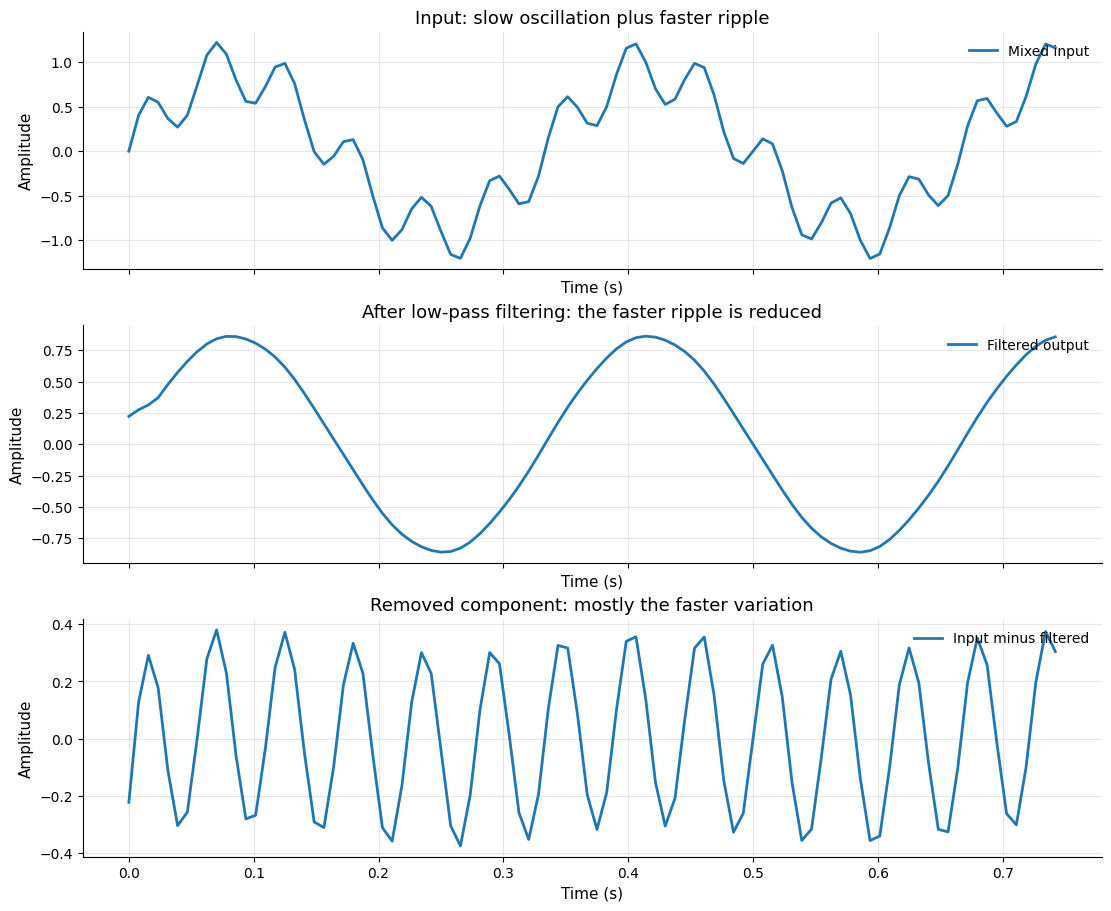

In [3]:
fs = 128.0
duration_s = 1.0
t = time_axis(int(fs * duration_s), fs)
x_slow = 0.9 * np.sin(2.0 * np.pi * 3.0 * t)
x_fast = 0.35 * np.sin(2.0 * np.pi * 18.0 * t)
x_mixed = x_slow + x_fast

h_lp = np.ones(7, dtype=float) / 7.0
y_lp = linear_convolve(x_mixed, h_lp, mode="same")

fig, axes = make_figure(nrows=3, ncols=1, figsize=(11.0, 9.0), sharex=True)
plot_signal(t[:96], x_mixed[:96], ax=axes[0], title="Input: slow oscillation plus faster ripple", xlabel="Time (s)", ylabel="Amplitude", label="Mixed input")
axes[0].legend(loc="upper right")
plot_signal(t[:96], y_lp[:96], ax=axes[1], title="After low-pass filtering: the faster ripple is reduced", xlabel="Time (s)", ylabel="Amplitude", label="Filtered output")
axes[1].legend(loc="upper right")
plot_signal(t[:96], x_mixed[:96] - y_lp[:96], ax=axes[2], title="Removed component: mostly the faster variation", xlabel="Time (s)", ylabel="Amplitude", label="Input minus filtered")
axes[2].legend(loc="upper right")
plt.show()


This is the same idea we saw spectrally in Notebook 03. Smoother kernels in time correspond to stronger emphasis on low-frequency behavior and reduced response to rapid fluctuation.


## Convolution Versus Correlation

Convolution flips the kernel before sliding it across the input. Correlation does not. That distinction disappears for symmetric kernels, but it matters for asymmetric reference waveforms.

The example below uses a deliberately asymmetric waveform with both positive and negative values so the difference is visually obvious. The purpose of the figure is to show that the correlation peak occurs where the reference best aligns with the received data, while the convolution output changes shape because the reference is flipped before the overlap is computed.

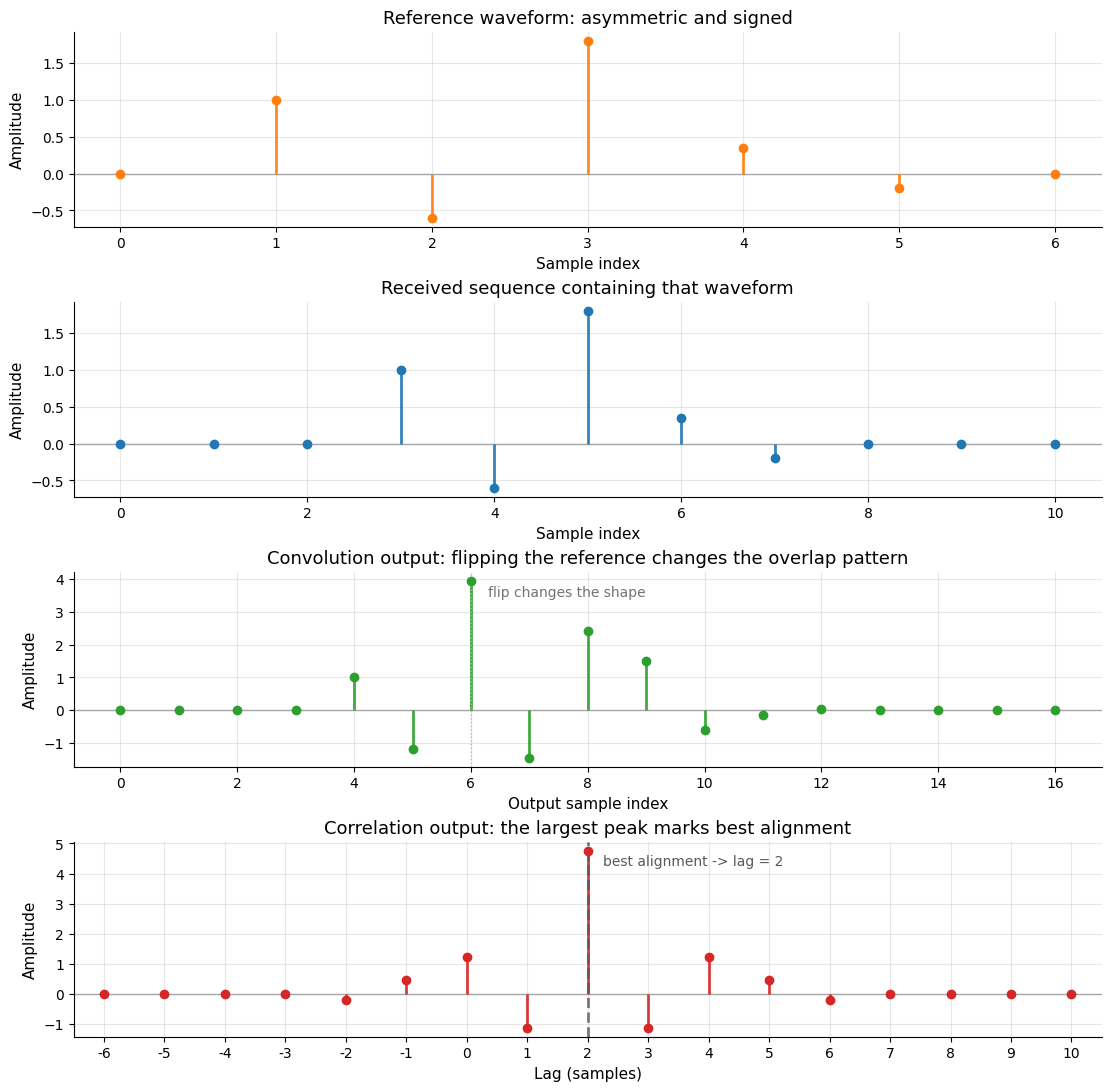

In [4]:
reference = np.array([0.0, 1.0, -0.6, 1.8, 0.35, -0.2, 0.0])
received = np.array([0.0, 0.0, 0.0, 1.0, -0.6, 1.8, 0.35, -0.2, 0.0, 0.0, 0.0])

conv_out = linear_convolve(received, reference, mode="full")
corr_out = correlate(received, reference, mode="full")
corr_lags = np.arange(-(len(reference) - 1), len(received))
peak_corr = int(np.argmax(np.abs(corr_out)))
peak_lag = int(corr_lags[peak_corr])

fig, axes = make_figure(nrows=4, ncols=1, figsize=(11.0, 10.8), sharex=False)
stem_like(axes[0], reference, title="Reference waveform: asymmetric and signed", color="C1")
stem_like(axes[1], received, title="Received sequence containing that waveform", color="C0")
stem_like(axes[2], conv_out, title="Convolution output: flipping the reference changes the overlap pattern", color="C2")
axes[2].set_xlabel("Output sample index")
axes[2].axvline(len(reference) - 1, color="0.7", linestyle=":", linewidth=1.0)
axes[2].text(len(reference) - 0.7, 0.88 * np.max(np.abs(conv_out)), "flip changes the shape", color="0.45")
stem_like(axes[3], corr_out, title="Correlation output: the largest peak marks best alignment", color="C3")
axes[3].set_xlabel("Lag (samples)")
axes[3].set_xlim(-0.5, len(corr_out) - 0.5)
axes[3].set_xticks(np.arange(len(corr_out)))
axes[3].set_xticklabels([str(v) for v in corr_lags])
axes[3].axvline(peak_corr, color="0.35", linestyle="--", alpha=0.8)
axes[3].text(peak_corr + 0.25, 0.9 * np.max(np.abs(corr_out)), f"best alignment -> lag = {peak_lag}", color="0.35")
plt.show()

Correlation is the better language when the question is "where does this known pattern appear in the data?" That is exactly the question behind delay estimation and echo detection.

In this figure, the correlation output preserves the reference orientation, so the dominant peak occurs where the signed shape best matches the received sequence. The convolution output is different because the reference is flipped first, which changes the overlap pattern and therefore changes the shape of the result.

## Matched Filtering Finds A Known Pulse In Noise

A matched filter is built from a known reference waveform. In the real-valued examples here, it is the time-reversed reference. For complex waveforms, it is the time-reversed conjugate reference.

That choice matters because it makes the convolution output behave like a correlation: the reversal creates the shifting-and-alignment behavior, and the conjugation preserves the correct phase-sensitive comparison for complex signals. When the received data contains that waveform, the matched-filter output adds the aligned samples coherently and produces a strong peak.

This is the core detection idea behind later ranging and pulse-compression notebooks.

In the example below, a known pulse is inserted into noisy data, and the figure is meant to show that matched filtering converts waveform alignment into a measurable peak location.

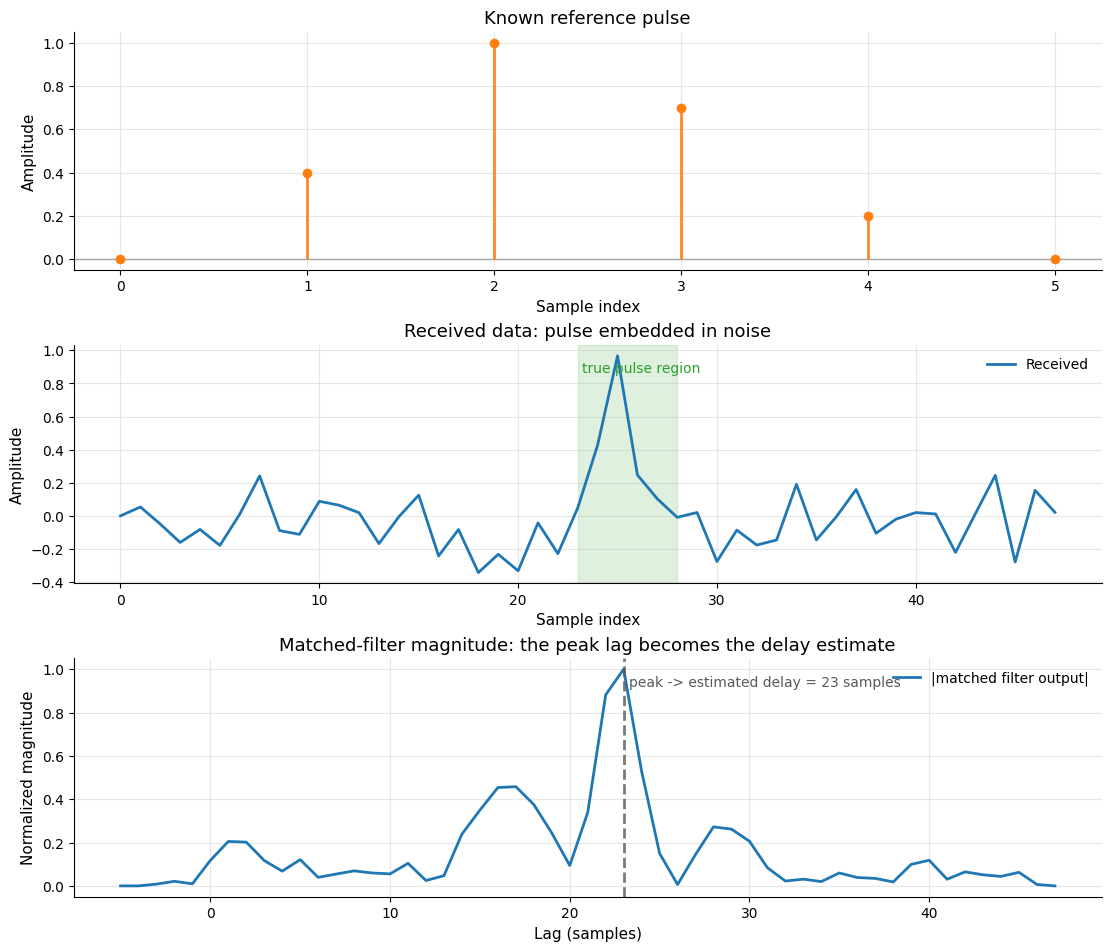

True insertion index: 23 samples
Estimated delay from matched-filter peak: 23 samples


In [5]:
rng = np.random.default_rng(7)
reference_pulse = np.array([0.0, 0.4, 1.0, 0.7, 0.2, 0.0])
received_noise = 0.18 * rng.normal(size=48)
insert_at = 23
received_pulse = received_noise.copy()
received_pulse[insert_at : insert_at + len(reference_pulse)] += reference_pulse

mf_out = matched_filter(received_pulse, reference_pulse, mode="full")
mf_lags = np.arange(-(len(reference_pulse) - 1), len(received_pulse))
peak_index = int(np.argmax(np.abs(mf_out)))
delay_est = int(mf_lags[peak_index])

fig, axes = make_figure(nrows=3, ncols=1, figsize=(11.0, 9.4), sharex=False)
stem_like(axes[0], reference_pulse, title="Known reference pulse", color="C1")
plot_signal(np.arange(len(received_pulse)), received_pulse, ax=axes[1], title="Received data: pulse embedded in noise", xlabel="Sample index", ylabel="Amplitude", label="Received")
axes[1].axvspan(insert_at, insert_at + len(reference_pulse) - 1, color="C2", alpha=0.15)
axes[1].text(insert_at + 0.2, 0.9 * np.max(received_pulse), "true pulse region", color="C2")
plot_signal(mf_lags, normalize(np.abs(mf_out)), ax=axes[2], title="Matched-filter magnitude: the peak lag becomes the delay estimate", xlabel="Lag (samples)", ylabel="Normalized magnitude", label="|matched filter output|")
axes[2].axvline(delay_est, color="0.35", linestyle="--", alpha=0.8)
axes[2].text(delay_est + 0.3, 0.92, f"peak -> estimated delay = {delay_est} samples", color="0.35")
axes[2].legend(loc="upper right")
plt.show()

print(f"True insertion index: {insert_at} samples")
print(f"Estimated delay from matched-filter peak: {delay_est} samples")

The matched-filter output is not magic. It is a weighted accumulation. When the reference lines up with the embedded pulse, many products have the same sign and reinforce one another. Away from alignment, the products do not add coherently, so the output stays smaller.

The reason this works is visible in the algebra above: the matched-filter kernel is chosen so that the convolution sum becomes a correlation-style similarity test against the reference waveform. In this real-valued example, the conjugation has no numerical effect, but the time reversal still matters because it creates the alignment test that produces the peak.

In this real-valued example, the matched filter and correlation produce their peak at the same lag. Because the horizontal axis is already expressed as lag, the peak location can be read directly as the delay estimate.

## Reference Note: Why Conjugation Matters For Complex Signals

This section is a short reference note rather than a new required concept for the rest of the notebook. Its purpose is to make clear why matched filters use the **time-reversed conjugate** reference for complex signals.

Suppose the received data and reference have the same local complex phase,

$$
x[n] = A e^{j\phi}, \qquad s[n] = B e^{j\phi}.
$$

If we multiply them directly without conjugation, then

$$
x[n] \, s[n] = AB e^{j\phi} e^{j\phi} = AB e^{j2\phi}.
$$

The phase does not cancel. It doubles. That is not the behavior we want from a similarity test.

If we multiply by the conjugated reference instead, then

$$
x[n] \, s^*[n] = AB e^{j\phi} e^{-j\phi} = AB.
$$

Now the phase cancels, so matching complex phase adds coherently. That is the key reason conjugation appears in correlation and matched filtering.

For complex signals, the two operations play different roles:

- the **time reversal** created by the negative sign handles sliding and time alignment,
- the **conjugation** handles phase alignment,
- and together they make the matched-filter output large only when both the waveform shape and its complex phase structure match the reference.

So when the notebook says that matched filtering is a convolution designed to behave like correlation, this is one of the main reasons: conjugation turns the product into a proper phase-sensitive similarity test. This is closely related to the reason Notebook 03 used a negative sign in the Fourier-transform reference exponential. In both cases, the reference is constructed so that matching phase cancels rather than adds, which is what allows coherent accumulation to reveal similarity.

## Tradeoffs And Limitations

Several practical tradeoffs are important to keep in mind:

- Smoothing filters reduce fast variation, but they also blur sharp transitions.
- Correlation is useful for finding known patterns, but it depends on having a good reference.
- Matched filtering creates strong peaks when the assumed waveform is correct, but mismatch in shape, timing, or phase reduces that gain.
- Real systems often care about causal implementation, finite precision, and computational cost, none of which these small examples emphasize.

This notebook also leaves out several important realities:

- colored noise rather than simple white noise,
- Doppler shifts that distort the reference waveform,
- complex-valued baseband pulse models,
- and FFT-based fast convolution for long sequences.


## Recap

- The impulse response tells us how an LTI system acts on any input.
- Convolution is the sliding weighted sum that produces the output of that system.
- Low-pass filters smooth rapid variation by averaging nearby samples.
- Correlation measures similarity and is natural for alignment and delay estimation.
- A matched filter is a correlation-like operation that produces a strong peak when a known waveform is present.


## Suggested Next Questions

- How does noise change detection reliability?
- How do false alarms and missed detections trade off against one another?
- How should we estimate signal power or noise power from finite data?

The next notebook turns to noise, detection, and estimation so these filtering ideas can be evaluated under uncertainty.
